# NB4 — SSL Backbone Comparison (HuBERT vs wav2vec2)

Reads `summary.json`, `evaluation_summary.json`, and `test_predictions.json` from
the two runs and produces the comparison figures. Corrections: WA/UA metrics,
non-truncated axes, same concept set for the interventions,
**McNemar between backbones** on the per-sample predictions.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys, json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJ = Path('/content/drive/MyDrive/Colab Notebooks/XAI_Project/XAI_SER/code')
sys.path.append(str(PROJ))
import xai_common as xc

BB  = ['hubert', 'wav2vec2']
COL = {'hubert': '#4C72B0', 'wav2vec2': '#DD8452'}
MK  = {'hubert': 'o', 'wav2vec2': 's'}
OUT = PROJ / 'compare'; OUT.mkdir(parents=True, exist_ok=True)

S, E, P = {}, {}, {}
for b in BB:
    res = xc.get_paths(b, PROJ)['results']
    S[b] = json.load(open(res / 'summary.json'))
    E[b] = json.load(open(res / 'evaluation_summary.json'))
    P[b] = json.load(open(res / 'test_predictions.json'))
print('Loaded:', BB)

def save(fig, name):
    fig.tight_layout(); fig.savefig(OUT / name, dpi=150, bbox_inches='tight'); plt.show()
    print('->', OUT / name)

Caricati: ['hubert', 'wav2vec2']


## 1 · Accuracy and UA (axes starting from 0)

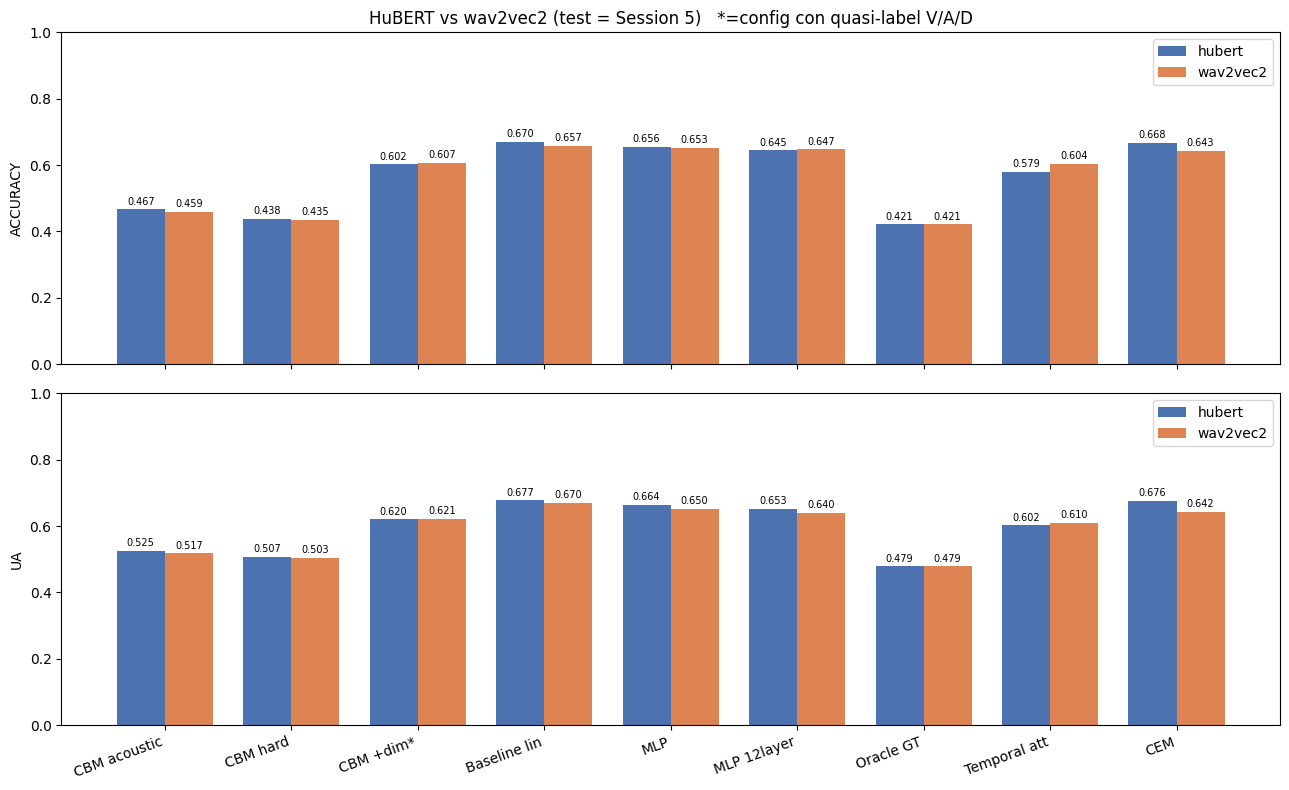

-> /content/drive/MyDrive/Colab Notebooks/XAI_Project/XAI_SER/code/compare/compare_accuracy.png


In [ ]:
models = [('CBM acoustic', lambda s: s['cbm']['acoustic']),
          ('CBM hard', lambda s: s['cbm_hard']),
          ('CBM +dim*', lambda s: s['cbm']['acoustic+dim']),
          ('Baseline lin', lambda s: s['baseline_linear']),
          ('MLP', lambda s: s['baseline_mlp']),
          ('MLP 12layer', lambda s: s['baseline_mlp_concat']),
          ('Oracle GT', lambda s: s['oracle_completeness']),
          ('Temporal att', lambda s: s['temporal_attention']),
          ('CEM', lambda s: s['cem'])]
x = np.arange(len(models)); w = 0.38
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for ax, metric in zip(axes, ['accuracy', 'ua']):
    for i, b in enumerate(BB):
        bar = ax.bar(x + (i - 0.5) * w, [fn(S[b])[metric] for _, fn in models], w, label=b, color=COL[b])
        ax.bar_label(bar, fmt='%.3f', fontsize=7, padding=2)
    ax.set_ylabel(metric.upper()); ax.set_ylim(0, 1)   # never truncate the axes
    ax.legend()
axes[0].set_title('HuBERT vs wav2vec2 (test = Session 5)   *=config with V/A/D quasi-labels')
axes[1].set_xticks(x); axes[1].set_xticklabels([m for m, _ in models], rotation=20, ha='right')
save(fig, 'compare_accuracy.png')

## 2 · Per-layer probing (validation)

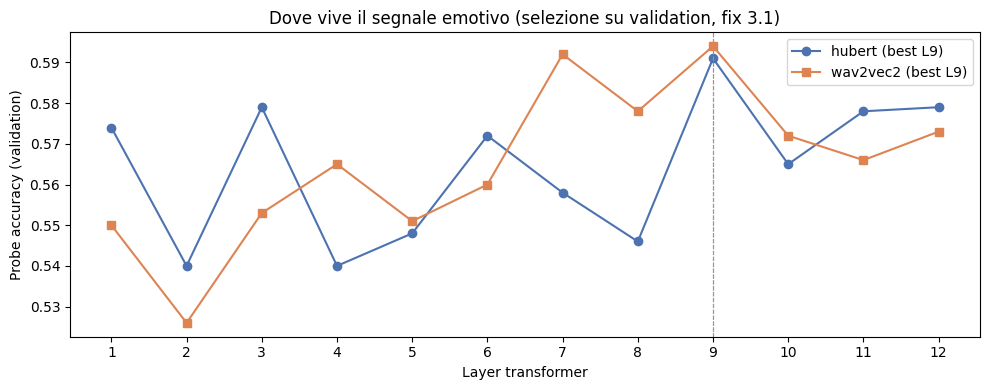

-> /content/drive/MyDrive/Colab Notebooks/XAI_Project/XAI_SER/code/compare/compare_layer_accuracy.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
for b in BB:
    la = S[b]['layer_val_accuracy']; best = int(np.argmax(la)) + 1
    ax.plot(range(1, len(la) + 1), la, marker=MK[b], color=COL[b], label=f'{b} (best L{best})')
    ax.axvline(best, color=COL[b], linestyle='--', linewidth=0.8)
ax.set_xticks(range(1, 13)); ax.set_xlabel('Transformer layer')
ax.set_ylabel('Probe accuracy (validation)')
ax.set_title('Where the emotional signal lives (selection on validation)')
ax.legend(); save(fig, 'compare_layer_accuracy.png')

## 3 · Intervention curves (same acoustic concept set)

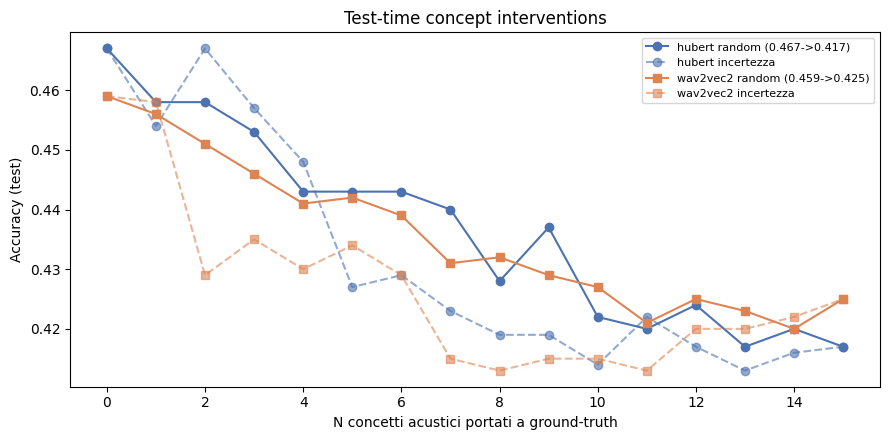

-> /content/drive/MyDrive/Colab Notebooks/XAI_Project/XAI_SER/code/compare/compare_intervention.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for b in BB:
    ic_r = S[b]['intervention_random_mean']
    ic_u = S[b]['intervention_uncertainty']
    ax.plot(range(len(ic_r)), ic_r, marker=MK[b], color=COL[b],
            label=f'{b} random ({ic_r[0]:.3f}->{ic_r[-1]:.3f})')
    ax.plot(range(len(ic_u)), ic_u, marker=MK[b], color=COL[b], linestyle='--', alpha=0.6,
            label=f'{b} uncertainty')
ax.set_xlabel('N acoustic concepts brought to ground truth'); ax.set_ylabel('Accuracy (test)')
ax.set_title('Test-time concept interventions')
ax.legend(fontsize=8); save(fig, 'compare_intervention.png')

## 4 · Concept decodability

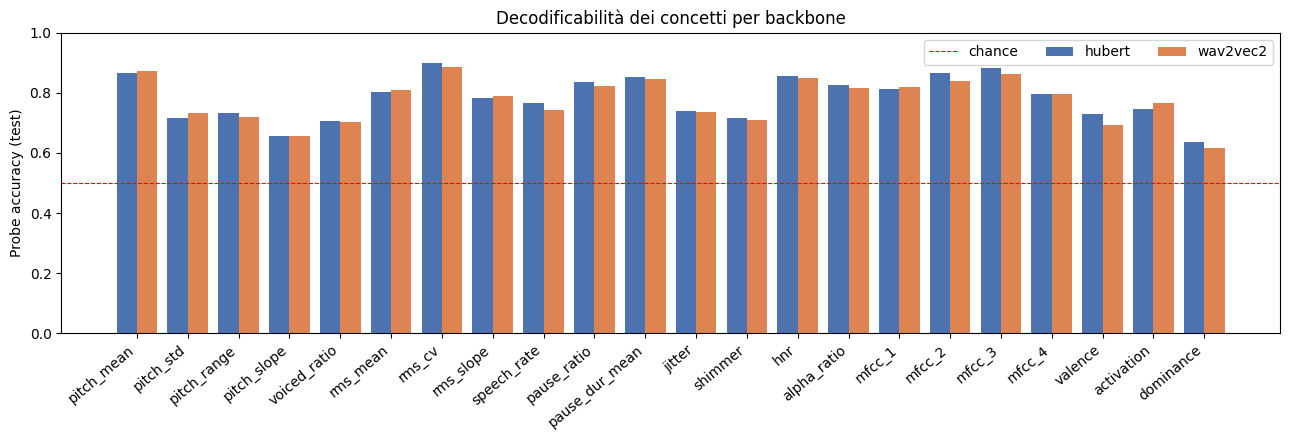

-> /content/drive/MyDrive/Colab Notebooks/XAI_Project/XAI_SER/code/compare/compare_probe_accuracy.png


In [ ]:
concepts = list(S[BB[0]]['probe_metrics'])
x = np.arange(len(concepts)); w = 0.4
fig, ax = plt.subplots(figsize=(13, 4.5))
for i, b in enumerate(BB):
    ax.bar(x + (i - 0.5) * w, [S[b]['probe_metrics'][c]['accuracy'] for c in concepts],
           w, label=b, color=COL[b])
ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, label='chance')
ax.set_xticks(x); ax.set_xticklabels(concepts, rotation=40, ha='right')
ax.set_ylabel('Probe accuracy (test)'); ax.set_ylim(0, 1)
ax.set_title('Concept decodability per backbone')
ax.legend(ncol=3); save(fig, 'compare_probe_accuracy.png')

## 5 · XAI metrics (Co-12)

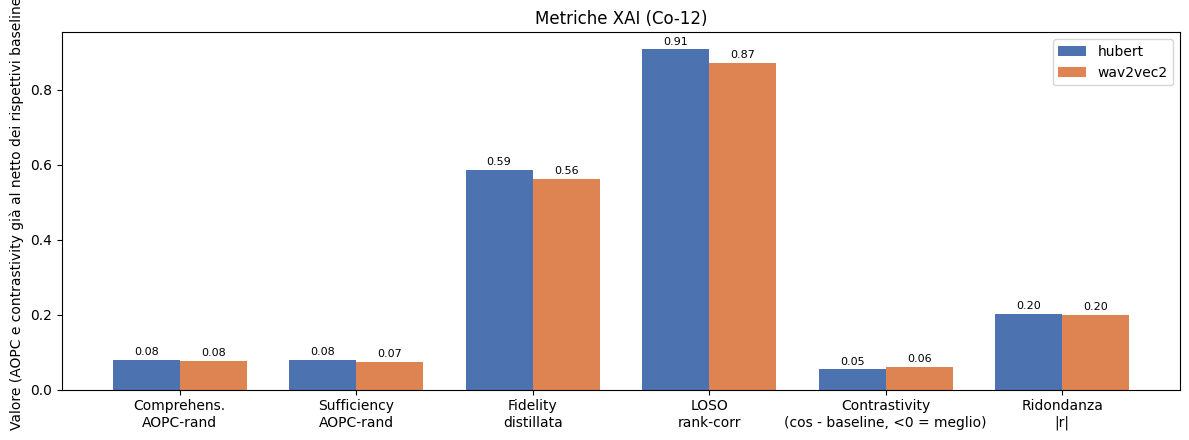

-> /content/drive/MyDrive/Colab Notebooks/XAI_Project/XAI_SER/code/compare/compare_xai_metrics.png


In [ ]:
mets = [('Comprehens.\nAOPC-rand', lambda d: d['faithfulness']['AOPC_comprehensiveness'] - d['faithfulness']['AOPC_comprehensiveness_random']),
        ('Sufficiency\nAOPC-rand', lambda d: d['faithfulness']['AOPC_sufficiency'] - d['faithfulness']['AOPC_sufficiency_random']),
        ('Fidelity\ndistilled', lambda d: d['faithfulness']['fidelity_distilled']),
        ('LOSO\nrank-corr', lambda d: d['consistency_loso']['rank_corr_mean']),
        ('Contrastivity\n(cos - baseline, <0 = better)', lambda d: d['contrastivity']['mean_cosine_offdiag'] - d['contrastivity']['structural_baseline']),
        ('Redundancy\n|r|', lambda d: d['covariate_complexity']['mean_abs_corr_offdiag'])]
x = np.arange(len(mets)); w = 0.38
fig, ax = plt.subplots(figsize=(12, 4.5))
for i, b in enumerate(BB):
    bar = ax.bar(x + (i - 0.5) * w, [f(E[b]) for _, f in mets], w, label=b, color=COL[b])
    ax.bar_label(bar, fmt='%.2f', fontsize=8, padding=2)
ax.set_xticks(x); ax.set_xticklabels([m for m, _ in mets])
ax.set_ylabel('Value (AOPC and contrastivity already net of their respective baselines)')
ax.set_title('XAI metrics (Co-12)'); ax.legend()
save(fig, 'compare_xai_metrics.png')

## 6 · Significance — McNemar between backbones
The accuracy differences between backbones are small: without a per-sample
test there's no way to tell if they're real. Comparison on the saved
predictions (same test set).

In [ ]:
yt = np.array(P['hubert']['y_true'])
assert (yt == np.array(P['wav2vec2']['y_true'])).all(), 'different test sets between backbones!'
for model in ['cbm', 'mlp', 'wa']:
    pa, pb = np.array(P['hubert'][model]), np.array(P['wav2vec2'][model])
    r = xc.mcnemar(yt, pa, pb)
    p_str = f"{r['p_value']:.2e}" if r['p_value'] < 1e-4 else f"{r['p_value']:.4f}"
    verdict = 'significant' if r['p_value'] < 0.05 else 'NOT significant'
    print(f"{model:8s} HuBERT vs wav2vec2: n_only_a={r['n_only_a']} n_only_b={r['n_only_b']} "
          f"p={p_str} -> difference {verdict} (alpha=0.05)")

cbm      HuBERT vs wav2vec2: n_only_a=167 n_only_b=157 p=0.6171 -> differenza NON significativa (alpha=0.05)
mlp      HuBERT vs wav2vec2: n_only_a=95 n_only_b=91 p=0.8260 -> differenza NON significativa (alpha=0.05)
wa       HuBERT vs wav2vec2: n_only_a=117 n_only_b=104 p=0.4196 -> differenza NON significativa (alpha=0.05)


## 7 · Summary table

In [ ]:
rows = [('CBM acoustic (acc/UA)', lambda b: f"{S[b]['cbm']['acoustic']['accuracy']:.3f}/{S[b]['cbm']['acoustic']['ua']:.3f}"),
        ('CBM hard', lambda b: f"{S[b]['cbm_hard']['accuracy']:.3f}"),
        ('MLP black-box', lambda b: f"{S[b]['baseline_mlp']['accuracy']:.3f}/{S[b]['baseline_mlp']['ua']:.3f}"),
        ('MLP 12 layer', lambda b: f"{S[b]['baseline_mlp_concat']['accuracy']:.3f}"),
        ('Oracle GT acoustic', lambda b: f"{S[b]['oracle_completeness']['accuracy']:.3f}"),
        ('CEM', lambda b: f"{S[b]['cem']['accuracy']:.3f}"),
        ('Temporal attention', lambda b: f"{S[b]['temporal_attention']['accuracy']:.3f}"),
        ('Best layer (val)', lambda b: str(S[b]['best_layer'])),
        ('r(alpha, probing)', lambda b: f"{S[b]['r_alpha_probe']:+.2f}"),
        ('Random interventions 0->all', lambda b: f"{S[b]['intervention_random_mean'][0]:.3f}->{S[b]['intervention_random_mean'][-1]:.3f}"),
        ('Distilled fidelity', lambda b: f"{E[b]['faithfulness']['fidelity_distilled']:.3f}"),
        ('LOSO rank-corr', lambda b: f"{E[b]['consistency_loso']['rank_corr_mean']:.3f}"),
        ('Plausibility (acoustic)', lambda b: E[b]['plausibility']['domain_alignment'])]
print(f'{"metric":26s} {BB[0]:>14s} {BB[1]:>14s}')
for name, fn in rows:
    print(f'{name:26s} {fn(BB[0]):>14s} {fn(BB[1]):>14s}')

metrica                            hubert       wav2vec2
CBM acoustic (acc/UA)         0.467/0.525    0.459/0.517
CBM hard                            0.438          0.435
MLP black-box                 0.656/0.664    0.653/0.650
MLP 12 layer                        0.645          0.647
Oracle GT acustici                  0.421          0.421
CEM                                 0.668          0.643
Temporal attention                  0.579          0.604
Best layer (val)                        9              7
r(alpha, probing)                   +0.26          +0.42
Interventi random 0->all     0.467->0.417   0.459->0.425
Fidelity distillata                 0.587          0.563
LOSO rank-corr                      0.908          0.871
Plausibility (acustici)             11/14          11/14
